# Synthetic Gaussian Pretraining Data --- Visualisation

Loads the saved synthetic dataset from `synthetic-gaussian-pretrain/` and produces
diagnostic figures, saving each to `synthetic-gaussian-pretrain/plots/`.

**Run `pretrain/generate_data.py` first to produce the dataset.**

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

%matplotlib inline

# Match plot_results.py style exactly
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 120,
    "font.family": "serif",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}",
})

# Add project root to path
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

In [2]:
# ============================================================
# CONFIG — edit these to match your generate_data.py settings
# ============================================================

MAIN_PATH = "/Users/georgeissa/Documents/AC/SPE-AC-VAE"
DATA_DIR  = os.path.join(MAIN_PATH, "Data", "datasets", "synthetic-gaussian-pretrain")
PLOTS_DIR = os.path.join(DATA_DIR, "plots")
BETA      = 10.0
DTAU      = 0.05

os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Data dir  : {DATA_DIR}")
print(f"Plots dir : {PLOTS_DIR}")

Data dir  : /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain
Plots dir : /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots


## 1 · Load dataset

In [3]:
G_hat   = np.loadtxt(os.path.join(DATA_DIR, "Ghat_clean.csv"),      delimiter=",")
G_tilde = np.loadtxt(os.path.join(DATA_DIR, "Gbins_synthetic.csv"), delimiter=",")
params  = np.loadtxt(os.path.join(DATA_DIR, "params.csv"), delimiter=",", skiprows=1)

mus    = params[:, 0]
sigmas = params[:, 1]
N, L_tau = G_hat.shape
taus = np.linspace(0.0, BETA - DTAU, L_tau)

print(f"N = {N},  L_tau = {L_tau}")
print(f"mu    : min={mus.min():.3f}   max={mus.max():.3f}   mean={mus.mean():.3f}")
print(f"sigma : min={sigmas.min():.3f}   max={sigmas.max():.3f}   mean={sigmas.mean():.3f}")
print(f"G(tau=0) : min={G_hat[:,0].min():.4f}   max={G_hat[:,0].max():.4f}")

N = 1000,  L_tau = 200
mu    : min=-0.499   max=0.499   mean=-0.003
sigma : min=0.300   max=2.996   mean=1.197
G(tau=0) : min=0.0918   max=0.9030


## 2 · Overview (6-panel figure)

Calls the built-in `visualize_synthetic_dataset` function — same figure saved during training.

- **(0,0)** Scatter $(\mu,\,\log\sigma)$ --- uniform rectangular cloud expected
- **(0,1)** Histogram of $\mu$ --- flat (Uniform)
- **(0,2)** Histogram of $\log\sigma$ --- flat (LogUniform)
- **(1,0)** Sample $G(\tau)$ curves coloured by $\mu$
- **(1,1)** Sample $A(\omega)$ curves coloured by $\mu$
- **(1,2)** $G(\tau{=}0)$ distribution spanning $[0,1]$

In [4]:
from pretrain.synthetic_data import visualize_synthetic_dataset  # type: ignore

save_path = os.path.join(PLOTS_DIR, "dataset_overview.pdf")
visualize_synthetic_dataset(DATA_DIR, BETA, DTAU, save_path=save_path, n_show=40)
print(f"Saved -> {save_path}")

  Dataset overview saved to: /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/dataset_overview.pdf
Saved -> /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/dataset_overview.pdf


## 3 · Parameter coverage check

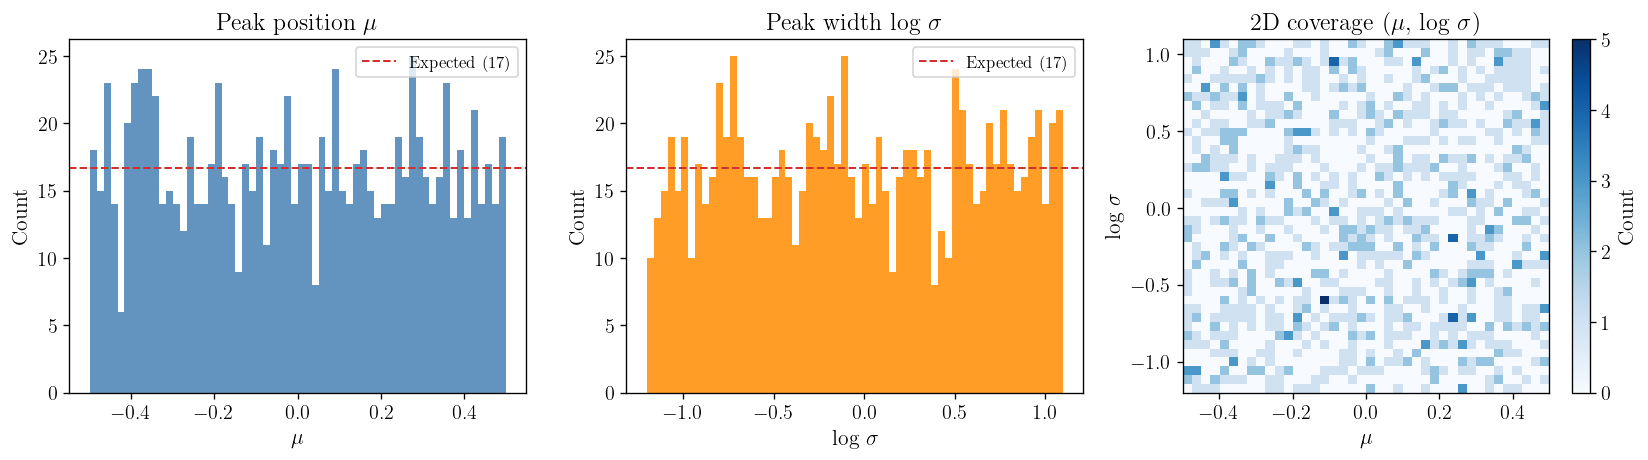

Saved -> /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/parameter_coverage.pdf


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

expected = N / 60  # expected count per bin for a flat distribution

# --- mu histogram ---
ax = axes[0]
ax.hist(mus, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
ax.axhline(expected, color="#D32F2F", linestyle="--", linewidth=1.2,
           label=rf"Expected ({expected:.0f})")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Count")
ax.set_title(r"Peak position $\mu$")
ax.legend()

# --- log-sigma histogram ---
ax = axes[1]
ax.hist(np.log(sigmas), bins=60, color="darkorange", edgecolor="none", alpha=0.85)
ax.axhline(expected, color="#D32F2F", linestyle="--", linewidth=1.2,
           label=rf"Expected ({expected:.0f})")
ax.set_xlabel(r"$\log\,\sigma$")
ax.set_ylabel("Count")
ax.set_title(r"Peak width $\log\,\sigma$")
ax.legend()

# --- 2D density ---
ax = axes[2]
h = ax.hist2d(mus, np.log(sigmas), bins=40, cmap="Blues")
plt.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\log\,\sigma$")
ax.set_title(r"2D coverage $(\mu,\,\log\,\sigma)$")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "parameter_coverage.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 4 · Green's function diversity

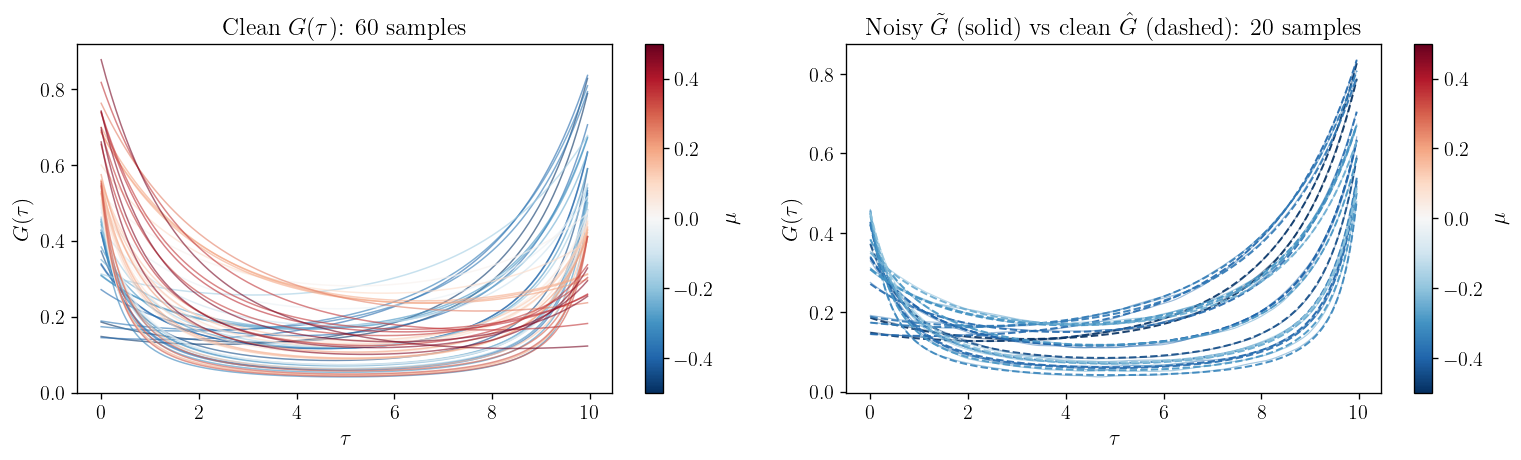

Saved -> /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/greens_functions.pdf


In [6]:
N_SHOW  = 60
rng_vis = np.random.default_rng(1)
idx     = rng_vis.choice(N, size=N_SHOW, replace=False)
idx     = idx[np.argsort(mus[idx])]   # sort by mu for clean color gradient

norm = plt.Normalize(mus.min(), mus.max())
cmap = cm.RdBu_r
sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Clean G(tau)
ax = axes[0]
for i in idx:
    ax.plot(taus, G_hat[i], color=cmap(norm(mus[i])), alpha=0.6, linewidth=0.9)
plt.colorbar(sm, ax=ax, label=r"$\mu$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$G(\tau)$")
ax.set_title(rf"Clean $G(\tau)$: {N_SHOW} samples")

# Noisy vs clean for 20 samples
ax = axes[1]
for i in idx[:20]:
    c = cmap(norm(mus[i]))
    ax.plot(taus, G_tilde[i], color=c, alpha=0.45, linewidth=0.7)
    ax.plot(taus, G_hat[i],   color=c, alpha=0.90, linewidth=1.2, linestyle="--")
plt.colorbar(sm, ax=ax, label=r"$\mu$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$G(\tau)$")
ax.set_title(r"Noisy $\tilde{G}$ (solid) vs clean $\hat{G}$ (dashed): 20 samples")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "greens_functions.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 4b · Noise statistics

The noisy Green's functions $\tilde{G}(\tau)$ are constructed as

$$\tilde{G}^{(n)}(\tau) = \hat{G}^{(n)}(\tau) + \eta^{(n)}(\tau), \qquad \eta \sim \mathcal{N}(0,\, C)$$

where $C$ is the **DQMC covariance matrix** estimated from real QMC bins.  The noise is drawn via the Cholesky factor: $\eta = L R$, $R \sim \mathcal{N}(0, I)$, $L L^\top = C$.

The two DQMC parameters that set the scale of $C$ are:

| Symbol | Name | Role |
|--------|------|------|
| $\sigma_s$ (`NOISE_S`) | noise floor | overall amplitude of QMC statistical error |
| $\xi$ (`NOISE_XI`) | correlation length | how correlated the noise is between nearby $\tau$-points |

**What the statistics measure:**

- **`diag(C)`** — variance $\langle \eta(\tau)^2 \rangle$ at each imaginary-time point; its square root is the per-point noise standard deviation.
- **`Tr(C)`** — total variance summed over all $\tau$-points; the average squared noise magnitude of a full Green's function vector.
- **Frobenius norm** $\|C\|_F = \sqrt{\sum_{ij} C_{ij}^2}$ — overall magnitude of the matrix, including off-diagonal correlations between different $\tau$-points.
- **Eigenvalues of $C$** — because $C$ is symmetric positive semi-definite its eigenvalues are the variances along the principal noise directions.  The largest eigenvalue sets the worst-case noise amplitude; the smallest sets the best-case.
- **Condition number** $\kappa = \lambda_{\max}/\lambda_{\min}$ — if $\kappa \gg 1$ the matrix is ill-conditioned: some $\tau$-directions are far noisier than others, which is exactly what the chi-squared loss accounts for via $C^{-1}$.
- **Relative noise** $\sqrt{C_{\tau\tau}}\,/\,|\hat{G}(\tau)|$ — signal-to-noise ratio at each $\tau$-point.  Peaks near $\tau = \beta/2$ where $G$ is small but noise is constant.

DQMC noise parameters
  xi      (tau-correlation length)  = 5.000e-01
  sigma_s (noise floor amplitude)   = 1.000e-05

Covariance matrix C  [200 x 200]
  Tr(C)  [total variance, E[||eta||^2]]     = 1.984e-03
  ||C||_F [Frobenius norm, incl. off-diag]  = 7.058e-04

  diag(C) — variance per tau-point:
    max  Var[eta(tau)]  = 1.056e-05   at tau_idx=99
    min  Var[eta(tau)]  = 9.071e-06   at tau_idx=23
    mean Var[eta(tau)]  = 9.919e-06

  sqrt(diag(C)) — noise std-dev per tau-point:
    max  std[eta(tau)]  = 3.249e-03   at tau=4.95
    min  std[eta(tau)]  = 3.012e-03   at tau=1.15
    mean std[eta(tau)]  = 3.149e-03

  Eigenvalues of C (principal noise variances):
    lambda_max  = 4.185e-04   (noisiest direction in tau-space)
    lambda_min  = 8.379e-21    (quietest direction; C^-1 amplifies this)
    kappa = lambda_max/lambda_min  = 4.995e+16  (condition number)
    -> kappa >> 1 means chi-squared loss MUST use C^-1 to weight directions correctly

  Relative noise std/|G(tau)|:
    

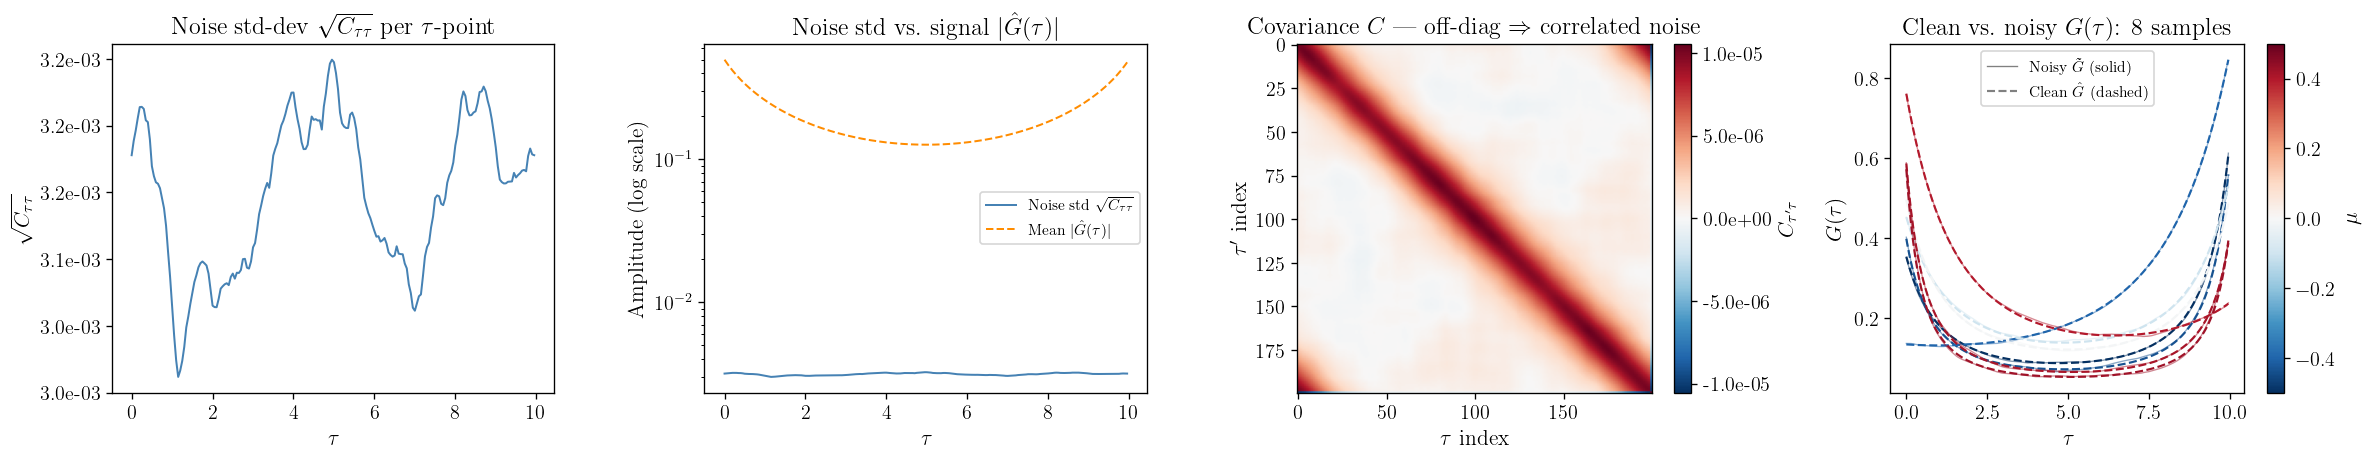

Saved -> /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/noise_statistics.pdf


In [7]:
# ---------------------------------------------------------------
# DQMC noise parameters — must match generate_data.py / run_pretrain_pipeline.py
# ---------------------------------------------------------------
NOISE_S  = 1e-5   # sigma_s : sets the overall amplitude of QMC statistical noise
NOISE_XI = 0.5    # xi      : correlation length — controls how strongly noise at
                  #           nearby tau-points is correlated

# Load the covariance matrix C saved during data generation.
# C was computed from the DQMC Gbins CSV (covariance_source), so it reflects
# the actual statistical structure of the measurement noise, not signal variance.
cov_path = os.path.join(DATA_DIR, "covariance.npy")
C = np.load(cov_path)                 # shape (L_tau, L_tau)

# --- Per-tau-point noise statistics ---
# diag(C)[l] = Var[eta(tau_l)] = <eta(tau_l)^2> : variance at each imaginary-time point.
# sqrt(diag(C)) is therefore the noise standard deviation at each tau.
diag        = np.diag(C)
std_per_tau = np.sqrt(diag)

# --- Eigendecomposition of C ---
# C is symmetric positive semi-definite, so eigvalsh returns real eigenvalues in
# ascending order.  Each eigenvalue is the variance along the corresponding
# principal noise direction in the L_tau-dimensional G(tau) space.
eigvals = np.linalg.eigvalsh(C)       # ascending: eigvals[0] = smallest, eigvals[-1] = largest

# --- Relative noise: how big is the noise compared to the signal? ---
# At each tau, we compare the noise std to the mean absolute signal |G(tau)|.
# This ratio blows up near tau = beta/2 where G is exponentially small.
G_mean_abs = np.abs(G_hat).mean(axis=0)          # mean |G(tau)| over all N samples
rel_noise  = std_per_tau / (G_mean_abs + 1e-12)  # avoid division by zero at G=0

# ---------------------------------------------------------------
# Print summary
# ---------------------------------------------------------------
print("=" * 62)
print("DQMC noise parameters")
print("=" * 62)
print(f"  xi      (tau-correlation length)  = {NOISE_XI:.3e}")
print(f"  sigma_s (noise floor amplitude)   = {NOISE_S:.3e}")
print()

# Tr(C) = sum of all diagonal entries = total variance across all L_tau points.
# It equals the expected value of ||eta||^2, the squared L2-norm of a noise vector.
print(f"Covariance matrix C  [{C.shape[0]} x {C.shape[1]}]")
print(f"  Tr(C)  [total variance, E[||eta||^2]]     = {np.trace(C):.3e}")

# ||C||_F includes off-diagonal entries, so it captures how correlated the noise
# is across tau-points.  If C were diagonal, ||C||_F = sqrt(Tr(C^2)).
print(f"  ||C||_F [Frobenius norm, incl. off-diag]  = {np.linalg.norm(C, 'fro'):.3e}")
print()

# Diagonal (per-point variance)
print(f"  diag(C) — variance per tau-point:")
print(f"    max  Var[eta(tau)]  = {diag.max():.3e}   at tau_idx={diag.argmax()}")
print(f"    min  Var[eta(tau)]  = {diag.min():.3e}   at tau_idx={diag.argmin()}")
print(f"    mean Var[eta(tau)]  = {diag.mean():.3e}")
print()

# Noise std per tau
print(f"  sqrt(diag(C)) — noise std-dev per tau-point:")
print(f"    max  std[eta(tau)]  = {std_per_tau.max():.3e}   at tau={taus[std_per_tau.argmax()]:.2f}")
print(f"    min  std[eta(tau)]  = {std_per_tau.min():.3e}   at tau={taus[std_per_tau.argmin()]:.2f}")
print(f"    mean std[eta(tau)]  = {std_per_tau.mean():.3e}")
print()

# Eigenvalue spectrum
print(f"  Eigenvalues of C (principal noise variances):")
print(f"    lambda_max  = {eigvals[-1]:.3e}   (noisiest direction in tau-space)")
print(f"    lambda_min  = {eigvals[0]:.3e}    (quietest direction; C^-1 amplifies this)")
print(f"    kappa = lambda_max/lambda_min  = {eigvals[-1]/eigvals[0]:.3e}  (condition number)")
print(f"    -> kappa >> 1 means chi-squared loss MUST use C^-1 to weight directions correctly")
print()

# Relative noise
print(f"  Relative noise std/|G(tau)|:")
print(f"    mean  = {rel_noise.mean():.3e}")
print(f"    max   = {rel_noise.max():.3e}   at tau={taus[rel_noise.argmax()]:.2f}  (G is small here)")

# ---------------------------------------------------------------
# Figures: 4-panel layout
#   (0) noise std per tau
#   (1) noise std vs signal |G| on log scale
#   (2) covariance matrix heatmap
#   (3) clean vs noisy G(tau) overlay for a handful of samples
# ---------------------------------------------------------------
N_OVERLAY = 8   # number of samples to overlay in panel (3)
rng_noise  = np.random.default_rng(7)
idx_ov     = rng_noise.choice(N, size=N_OVERLAY, replace=False)
idx_ov     = idx_ov[np.argsort(mus[idx_ov])]   # sort by mu for a colour gradient

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# --- Panel 0: noise std per tau-point ---
# Shows sqrt(C_ll): the marginal noise std at each imaginary-time slice.
# The shape is set by xi (width of correlations) and sigma_s (overall scale).
ax = axes[0]
ax.plot(taus, std_per_tau, color="steelblue", linewidth=1.2)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\sqrt{C_{\tau\tau}}$")
ax.set_title(r"Noise std-dev $\sqrt{C_{\tau\tau}}$ per $\tau$-point")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1e}"))

# --- Panel 1: noise std vs mean |G| signal (log scale) ---
# Comparing the two on log scale shows where the signal is buried in noise
# (rel_noise > 1) vs. where it dominates (rel_noise < 1).
ax = axes[1]
ax.semilogy(taus, std_per_tau,  color="steelblue",  linewidth=1.2, label=r"Noise std $\sqrt{C_{\tau\tau}}$")
ax.semilogy(taus, G_mean_abs,   color="darkorange",  linewidth=1.2, linestyle="--", label=r"Mean $|\hat{G}(\tau)|$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Amplitude (log scale)")
ax.set_title(r"Noise std vs.\ signal $|\hat{G}(\tau)|$")
ax.legend(fontsize=9)

# --- Panel 2: full covariance matrix heatmap ---
# Off-diagonal entries C_{l'l} show noise correlations between tau-points.
# A diagonal C would mean noise at different tau's is independent (white noise).
# The actual C has structure set by xi: nearby tau-points share correlated noise.
ax = axes[2]
vmax = np.abs(C).max()
im   = ax.imshow(C, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label=r"$C_{\tau'\tau}$",
             format=plt.FuncFormatter(lambda v, _: f"{v:.1e}"))
ax.set_xlabel(r"$\tau$ index")
ax.set_ylabel(r"$\tau'$ index")
ax.set_title(r"Covariance $C$ — off-diag $\Rightarrow$ correlated noise")

# --- Panel 3: clean vs noisy G(tau) overlay ---
# Overlaying G_hat (clean, dashed) with G_tilde (noisy, solid) for a few samples
# gives a direct visual sense of how much the noise perturbs the signal.
ax = axes[3]
for i in idx_ov:
    c = cmap(norm(mus[i]))
    ax.plot(taus, G_tilde[i], color=c, alpha=0.5,  linewidth=0.8)
    ax.plot(taus, G_hat[i],   color=c, alpha=1.0,  linewidth=1.3, linestyle="--")
# Dummy lines for the legend
ax.plot([], [], color="grey", linewidth=0.8,              label=r"Noisy $\tilde{G}$ (solid)")
ax.plot([], [], color="grey", linewidth=1.3, linestyle="--", label=r"Clean $\hat{G}$ (dashed)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$G(\tau)$")
ax.set_title(rf"Clean vs.\ noisy $G(\tau)$: {N_OVERLAY} samples")
ax.legend(fontsize=9)
plt.colorbar(sm, ax=ax, label=r"$\mu$")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "noise_statistics.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 5 · Spectral function diversity

In [ ]:
omega_grid = np.linspace(-8.0, 8.0, 400)

fig, ax = plt.subplots(figsize=(8, 4))
for i in idx:
    A = np.exp(-0.5 * ((omega_grid - mus[i]) / sigmas[i])**2) / (sigmas[i] * np.sqrt(2 * np.pi))
    ax.plot(omega_grid, A, color=cmap(norm(mus[i])), alpha=0.55, linewidth=0.8)

plt.colorbar(sm, ax=ax, label=r"$\mu$")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$A(\omega)$")
ax.set_title(rf"Spectral functions $A(\omega)$: {N_SHOW} samples")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "spectral_functions.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")